<a href="https://colab.research.google.com/github/mayank454eng/AIML/blob/main/Copy_of_Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

In [23]:
import kagglehub
kazanova_sentiment140_path = kagglehub.dataset_download('kazanova/sentiment140')
kashishparmar02_social_media_sentiments_analysis_dataset_path = kagglehub.dataset_download('kashishparmar02/social-media-sentiments-analysis-dataset')
prakharrathi25_google_play_store_reviews_path = kagglehub.dataset_download('prakharrathi25/google-play-store-reviews')

print('Data source import complete.')

Using Colab cache for faster access to the 'sentiment140' dataset.
Using Colab cache for faster access to the 'social-media-sentiments-analysis-dataset' dataset.
Using Colab cache for faster access to the 'google-play-store-reviews' dataset.
Data source import complete.


In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import nltk
nltk.download('maxent_ne_chunker_tab')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('words')
nltk.download('vader_lexicon')
from nltk import word_tokenize , pos_tag
import matplotlib.pyplot as plt
plt.style.use('ggplot')


[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [25]:
df = pd.read_csv('reviews.csv')
print(df.shape)
df = df.head(1000)
print(df.shape)

(12495, 12)
(1000, 12)


In [26]:
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo
5,gp:AOqpTOEvElPsBa6k8rLDmk-WrEoJea98KUrIGYWodJe...,Jon Clemens,https://play-lh.googleusercontent.com/-q6L1fx0...,It has changed how I viewed my different lists...,1,1,5.6.0.7,2020-10-26 05:04:20,Please note that in order to sort the lists by...,2020-10-26 14:56:25,newest,com.anydo
6,gp:AOqpTOGHb-APKKMNFyL1OwuGq1AGW6bQp5aYYxSHvJx...,Gale W,https://play-lh.googleusercontent.com/a-/AOh14...,I'm only looking for a grocery list app but ev...,1,0,5.6.0.6,2020-10-25 23:40:46,Sorry about that. We are not aware of any issu...,2020-10-26 14:53:42,newest,com.anydo
7,gp:AOqpTOEcxvv_c0CK3G5tHjxXsGSjbzD65OQ3og02p-q...,No One,https://play-lh.googleusercontent.com/a-/AOh14...,"Reset my free trial, new phone I'd like to see...",1,0,5.5.0.8,2020-10-25 19:18:13,We have an extensive Help Center detailing how...,2020-10-26 14:43:36,newest,com.anydo
8,gp:AOqpTOHVgr7_qOhORsfPwnVCqX-n98dJ1Ksrps6q52p...,I Dewa Gede Nopi Ariana,https://play-lh.googleusercontent.com/a-/AOh14...,How do to stop monthly payment because i don't...,1,0,5.6.0.7,2020-10-25 10:09:00,Please note that you may cancel your subscript...,2020-10-26 14:39:59,newest,com.anydo
9,gp:AOqpTOHQ_paQ_ffWsMqGOWmMsPxs-pBkBgR_3H63WJv...,John Riddle,https://play-lh.googleusercontent.com/a-/AOh14...,I complain about not crashes and it was immedi...,1,1,5.6.0.7,2020-10-23 03:15:01,We are unaware of any issues with the app not ...,2020-10-25 17:11:06,newest,com.anydo


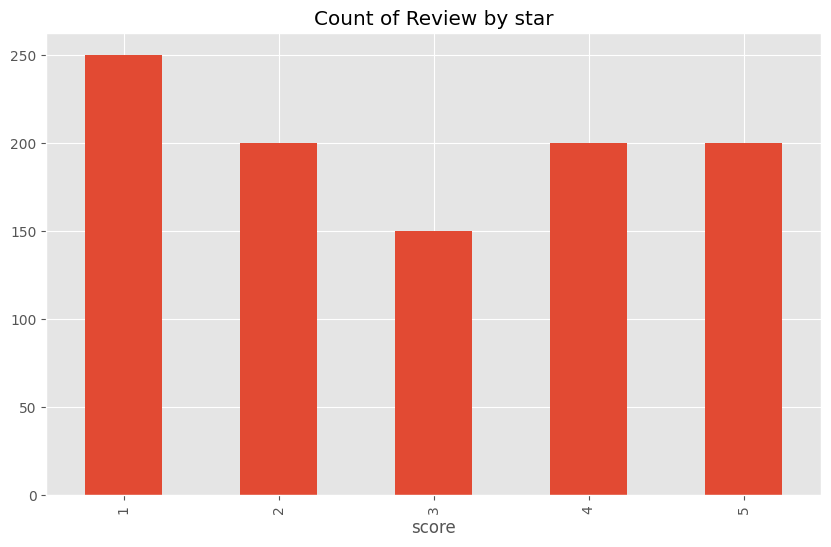

In [27]:
ax = df['score'].value_counts().sort_index()\
  .plot(kind='bar',
        title='Count of Review by star',
        figsize=(10,6))
plt.show()

In [28]:
example = df['content'][22]
print(example)

They recently started sending spammy notifications every week or so. Please stop.


In [32]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['They',
 'recently',
 'started',
 'sending',
 'spammy',
 'notifications',
 'every',
 'week',
 'or',
 'so']

In [35]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('They', 'PRP'),
 ('recently', 'RB'),
 ('started', 'VBD'),
 ('sending', 'VBG'),
 ('spammy', 'NN'),
 ('notifications', 'NNS'),
 ('every', 'DT'),
 ('week', 'NN'),
 ('or', 'CC'),
 ('so', 'RB')]

In [38]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  They/PRP
  recently/RB
  started/VBD
  sending/VBG
  spammy/NN
  notifications/NNS
  every/DT
  week/NN
  or/CC
  so/RB
  ./.
  Please/NNP
  stop/NN
  ./.)


In [43]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
sia = SentimentIntensityAnalyzer()

### Recalculate sentiment scores for the expanded DataFrame

Since `df` now contains 1000 rows, we need to re-calculate the sentiment scores for all these reviews before merging them into `vaders`.

In [44]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['content']
    res[i] = sia.polarity_scores(text)

  0%|          | 0/1000 [00:00<?, ?it/s]

### Recreate the `vaders` DataFrame

Now that `res` is updated, we can recreate the `vaders` DataFrame by merging the new sentiment scores with the `df`.

In [45]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, left_on='Id', right_index=True, how='left')
display(vaders.head())

,Id,neg,neu,pos,compound,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,0,0.000,1.000,0.000,0.0000,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,1,0.000,1.000,0.000,0.0000,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,2,0.042,0.809,0.149,0.6597,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,3,0.202,0.772,0.026,-0.8576,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,4,0.000,1.000,0.000,0.0000,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


In [46]:
sia.polarity_scores('I am so happy ')

{'neg': 0.0, 'neu': 0.334, 'pos': 0.666, 'compound': 0.6115}

In [47]:
sia.polarity_scores('This is the worst thing ever')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [48]:
sia.polarity_scores(example)

{'neg': 0.16, 'neu': 0.646, 'pos': 0.193, 'compound': 0.1313}

In [49]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, left_on='Id', right_index=True, how='left')

In [50]:
vaders.head(50)

,Id,neg,neu,pos,compound,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,0,0.000,1.000,0.000,0.0000,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,1,0.000,1.000,0.000,0.0000,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,2,0.042,0.809,0.149,0.6597,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,3,0.202,0.772,0.026,-0.8576,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,4,0.000,1.000,0.000,0.0000,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo
5,5,0.000,1.000,0.000,0.0000,gp:AOqpTOEvElPsBa6k8rLDmk-WrEoJea98KUrIGYWodJe...,Jon Clemens,https://play-lh.googleusercontent.com/-q6L1fx0...,It has changed how I viewed my different lists...,1,1,5.6.0.7,2020-10-26 05:04:20,Please note that in order to sort the lists by...,2020-10-26 14:56:25,newest,com.anydo
6,6,0.028,0.944,0.028,-0.0039,gp:AOqpTOGHb-APKKMNFyL1OwuGq1AGW6bQp5aYYxSHvJx...,Gale W,https://play-lh.googleusercontent.com/a-/AOh14...,I'm only looking for a grocery list app but ev...,1,0,5.6.0.6,2020-10-25 23:40:46,Sorry about that. We are not aware of any issu...,2020-10-26 14:53:42,newest,com.anydo
7,7,0.000,0.535,0.465,0.8271,gp:AOqpTOEcxvv_c0CK3G5tHjxXsGSjbzD65OQ3og02p-q...,No One,https://play-lh.googleusercontent.com/a-/AOh14...,"Reset my free trial, new phone I'd like to see...",1,0,5.5.0.8,2020-10-25 19:18:13,We have an extensive Help Center detailing how...,2020-10-26 14:43:36,newest,com.anydo
8,8,0.167,0.833,0.000,-0.2960,gp:AOqpTOHVgr7_qOhORsfPwnVCqX-n98dJ1Ksrps6q52p...,I Dewa Gede Nopi Ariana,https://play-lh.googleusercontent.com/a-/AOh14...,How do to stop monthly payment because i don't...,1,0,5.6.0.7,2020-10-25 10:09:00,Please note that you may cancel your subscript...,2020-10-26 14:39:59,newest,com.anydo
9,9,0.043,0.957,0.000,-0.4438,gp:AOqpTOHQ_paQ_ffWsMqGOWmMsPxs-pBkBgR_3H63WJv...,John Riddle,https://play-lh.googleusercontent.com/a-/AOh14...,I complain about not crashes and it was immedi...,1,1,5.6.0.7,2020-10-23 03:15:01,We are unaware of any issues with the app not ...,2020-10-25 17:11:06,newest,com.anydo


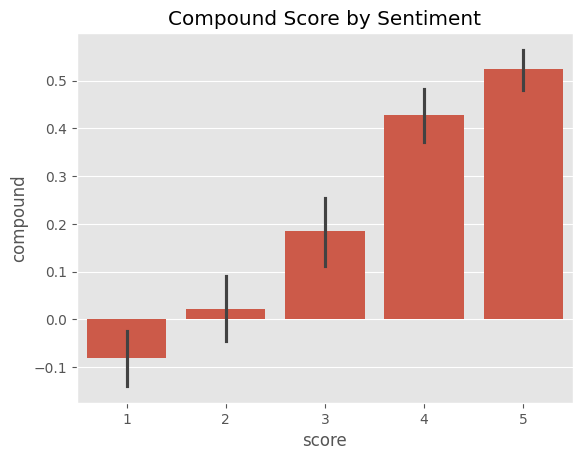

In [51]:
ax= sns.barplot(data = vaders, x='score' , y='compound')
ax.set_title('Compound Score by Sentiment')
plt.show(5)

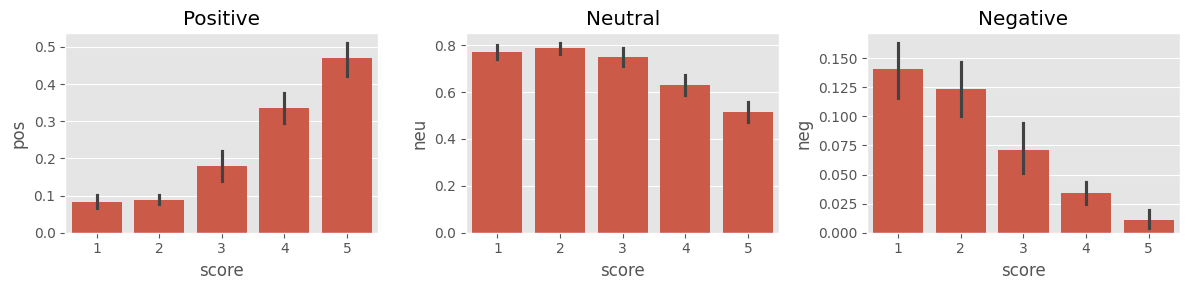

In [52]:
fig,axs = plt.subplots(1,3,figsize=(12,3))
sns.barplot(data=vaders,x='score',y='pos',ax=axs[0])
sns.barplot(data=vaders,x='score',y='neu',ax=axs[1])
sns.barplot(data=vaders,x='score',y='neg',ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()